# CatBoost Model Tuning for Customer Churn
This notebook trains a CatBoost classifier on the merged feature dataset, performs hyperparameter tuning, and reports the best parameter set for churn prediction.

Optimization target: **PR-AUC** (Average Precision), which is useful for imbalanced churn data.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

from catboost import CatBoostClassifier
from sklearn.base import clone
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedGroupKFold

pd.set_option('display.max_columns', None)

In [14]:
data_path = Path('../../data/04_merged/final_merged_features.csv')
df = pd.read_csv(data_path, low_memory=False)
df.columns = df.columns.str.lower().str.strip()

target_col = 'prospect_outcome'
valid_targets = ['Won', 'Churned']
model_threshold = 0.49

if target_col not in df.columns:
    raise ValueError(f"Target column '{target_col}' not found in {data_path}")

df[target_col] = df[target_col].astype(str).str.strip()
df = df[df[target_col].isin(valid_targets)].copy()
df['target'] = (df[target_col] == 'Churned').astype(int)

groups = df['co_ref'].astype(str).fillna('missing_co_ref')

drop_cols = [target_col, 'co_ref']
date_like_cols = [c for c in df.columns if 'date' in c.lower()]
feature_drop_cols = sorted(set(drop_cols + date_like_cols))

X = df.drop(columns=feature_drop_cols + ['target'], errors='ignore').copy()
y = df['target'].copy()

categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
if categorical_cols:
    X[categorical_cols] = X[categorical_cols].fillna('Missing').astype(str)

cat_feature_indices = [X.columns.get_loc(col) for col in categorical_cols]

print('Dataset shape (after target filtering):', df.shape)
print('Feature matrix shape:', X.shape)
print('Unique customers (groups):', groups.nunique())
print('Target distribution:')
print(df[target_col].value_counts().to_string())
print('Positive rate (churn):', round(y.mean(), 4))
print('Categorical features:', len(categorical_cols))
print('Numeric features:', X.shape[1] - len(categorical_cols))
print('Operating threshold:', model_threshold)

Dataset shape (after target filtering): (117321, 57)
Feature matrix shape: (117321, 49)
Unique customers (groups): 16567
Target distribution:
prospect_outcome
Won        102310
Churned     15011
Positive rate (churn): 0.1279
Categorical features: 2
Numeric features: 47
Operating threshold: 0.49


In [15]:
pos = int((y == 1).sum())
neg = int((y == 0).sum())
scale_pos_weight = neg / max(pos, 1)

cv_tune = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=42)

param_distributions = {
    'iterations': [200, 400, 600],
    'depth': [4, 6, 8],
    'learning_rate': [0.02, 0.05, 0.1],
    'l2_leaf_reg': [3, 5, 7, 9],
    'random_strength': [1.0, 2.0, 3.0],
    'border_count': [64, 128],
    'rsm': [0.7, 0.9, 1.0],
    'min_data_in_leaf': [1, 10, 20],
    'scale_pos_weight': [scale_pos_weight * 0.9, scale_pos_weight, scale_pos_weight * 1.1],
}

base_model = CatBoostClassifier(
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=0,
    allow_writing_files=False,
    thread_count=-1,
)

search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=8,
    scoring='average_precision',
    cv=cv_tune,
    random_state=42,
    refit=True,
    n_jobs=1,
    verbose=1,
    return_train_score=False,
 )

search.fit(X, y, groups=groups, cat_features=cat_feature_indices)

print('Best CV PR-AUC:', round(search.best_score_, 6))
print('Best Parameters:')
for k, v in search.best_params_.items():
    print(f'  {k}: {v}')

Fitting 2 folds for each of 8 candidates, totalling 16 fits
Best CV PR-AUC: 0.709569
Best Parameters:
  scale_pos_weight: 7.497235360735461
  rsm: 1.0
  random_strength: 2.0
  min_data_in_leaf: 10
  learning_rate: 0.02
  l2_leaf_reg: 7
  iterations: 600
  depth: 6
  border_count: 64


In [16]:
cv_results = pd.DataFrame(search.cv_results_).sort_values('rank_test_score').reset_index(drop=True)

result_cols = [
    'rank_test_score',
    'mean_test_score',
    'std_test_score',
    'param_iterations',
    'param_depth',
    'param_learning_rate',
    'param_l2_leaf_reg',
    'param_random_strength',
    'param_border_count',
    'param_rsm',
    'param_min_data_in_leaf',
    'param_scale_pos_weight',
]

cv_results[result_cols].head(10)

,rank_test_score,mean_test_score,std_test_score,param_iterations,param_depth,param_learning_rate,param_l2_leaf_reg,param_random_strength,param_border_count,param_rsm,param_min_data_in_leaf,param_scale_pos_weight
0,1,0.709569,0.001805,600,6,0.02,7,2.0,64,1.0,10,7.497235
1,2,0.706674,0.005238,400,6,0.02,7,3.0,64,1.0,10,6.815669
2,3,0.705802,0.001243,400,8,0.02,5,1.0,128,0.7,1,6.134102
3,4,0.705184,0.001204,600,4,0.05,7,3.0,128,1.0,1,6.815669
4,5,0.701007,0.002408,200,6,0.02,5,1.0,128,0.9,20,6.134102
5,6,0.699931,0.007796,200,4,0.05,9,3.0,64,0.9,10,7.497235
6,7,0.690589,0.005590,600,8,0.05,5,1.0,128,0.7,1,7.497235
7,8,0.688855,0.004395,200,8,0.10,5,1.0,64,0.7,10,6.815669


In [17]:
best_model = search.best_estimator_
cv_eval = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

oof_proba = np.zeros(len(X), dtype=float)
fold_metrics = []

for fold, (train_idx, valid_idx) in enumerate(cv_eval.split(X, y, groups), start=1):
    model = clone(best_model)
    X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
    y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

    model.fit(X_train, y_train, cat_features=cat_feature_indices)
    valid_proba = model.predict_proba(X_valid)[:, 1]
    valid_pred = (valid_proba >= model_threshold).astype(int)

    oof_proba[valid_idx] = valid_proba

    fold_metrics.append({
        'fold': fold,
        'pr_auc': average_precision_score(y_valid, valid_proba),
        'roc_auc': roc_auc_score(y_valid, valid_proba),
        f'precision@{model_threshold:.2f}': precision_score(y_valid, valid_pred, zero_division=0),
        f'recall@{model_threshold:.2f}': recall_score(y_valid, valid_pred, zero_division=0),
        f'f1@{model_threshold:.2f}': f1_score(y_valid, valid_pred, zero_division=0),
        f'accuracy@{model_threshold:.2f}': accuracy_score(y_valid, valid_pred),
    })

fold_metrics_df = pd.DataFrame(fold_metrics)
fold_metrics_df

,fold,pr_auc,roc_auc,precision@0.49,recall@0.49,f1@0.49,accuracy@0.49
0,1,0.734048,0.903853,0.513861,0.759494,0.612986,0.877301
1,2,0.733033,0.904555,0.504611,0.765490,0.608258,0.873849
2,3,0.736589,0.889415,0.532511,0.790876,0.636473,0.884381
3,4,0.701358,0.882243,0.484411,0.703864,0.573873,0.866263
4,5,0.702532,0.885472,0.484151,0.707195,0.574794,0.866135


OOF Metrics (5-fold StratifiedGroupCV) @ threshold=0.49:


,score
PR-AUC,0.720295
ROC-AUC,0.892953
Precision@0.49,0.504054
Recall@0.49,0.745387
F1@0.49,0.601414
Accuracy@0.49,0.873586


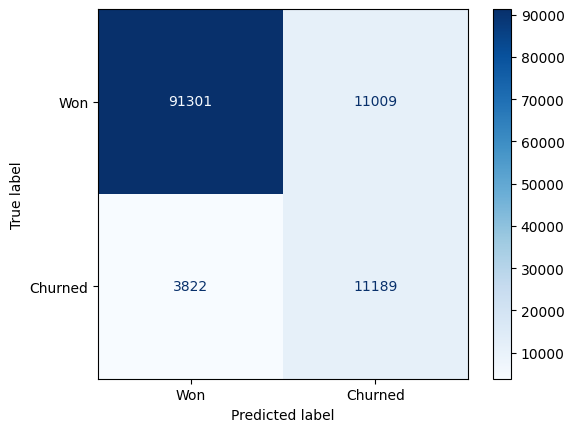

In [18]:
oof_pred = (oof_proba >= model_threshold).astype(int)

summary_metrics = pd.Series({
    'PR-AUC': average_precision_score(y, oof_proba),
    'ROC-AUC': roc_auc_score(y, oof_proba),
    f'Precision@{model_threshold:.2f}': precision_score(y, oof_pred, zero_division=0),
    f'Recall@{model_threshold:.2f}': recall_score(y, oof_pred, zero_division=0),
    f'F1@{model_threshold:.2f}': f1_score(y, oof_pred, zero_division=0),
    f'Accuracy@{model_threshold:.2f}': accuracy_score(y, oof_pred),
}).round(6)

print(f'OOF Metrics (5-fold StratifiedGroupCV) @ threshold={model_threshold:.2f}:')
display(summary_metrics.to_frame(name='score'))

cm = confusion_matrix(y, oof_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Won', 'Churned'])
disp.plot(cmap='Blues')

In [19]:
final_model = clone(best_model)
final_model.fit(X, y, cat_features=cat_feature_indices)

models_dir = Path('../../models')
models_dir.mkdir(parents=True, exist_ok=True)

model_artifact = {
    'model': final_model,
    'feature_names': X.columns.tolist(),
    'cat_feature_names': categorical_cols,
    'cat_feature_indices': cat_feature_indices,
    'best_params': search.best_params_,
    'best_cv_pr_auc': float(search.best_score_),
    'decision_threshold': model_threshold,
}

model_path = models_dir / 'best_catboost_tuned_model.joblib'
params_path = models_dir / 'catboost_best_params.json'
tuning_results_path = models_dir / 'catboost_tuning_results.csv'

joblib.dump(model_artifact, model_path)
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(model_artifact['best_params'], f, indent=2)

cv_results.to_csv(tuning_results_path, index=False)

print('Saved model artifact:', model_path.resolve())
print('Saved best params:', params_path.resolve())
print('Saved tuning results:', tuning_results_path.resolve())

Saved model artifact: C:\Users\AdimoolamNitinJagadi\Desktop\Code\04_DS\customer-churn-prediction\models\best_catboost_tuned_model.joblib
Saved best params: C:\Users\AdimoolamNitinJagadi\Desktop\Code\04_DS\customer-churn-prediction\models\catboost_best_params.json
Saved tuning results: C:\Users\AdimoolamNitinJagadi\Desktop\Code\04_DS\customer-churn-prediction\models\catboost_tuning_results.csv


In [20]:
print('Best CV PR-AUC (search):', round(search.best_score_, 6))
print('Best Params:', search.best_params_)

print('\nOOF Summary Metrics:')
print(summary_metrics.to_string())

print('\nFold metrics mean:')
print(fold_metrics_df.drop(columns=['fold']).mean().round(6).to_string())

tn, fp, fn, tp = cm.ravel()
print('\nConfusion matrix counts:')
print({'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp)})

Best CV PR-AUC (search): 0.709569
Best Params: {'scale_pos_weight': 7.497235360735461, 'rsm': 1.0, 'random_strength': 2.0, 'min_data_in_leaf': 10, 'learning_rate': 0.02, 'l2_leaf_reg': 7, 'iterations': 600, 'depth': 6, 'border_count': 64}

OOF Summary Metrics:
PR-AUC            0.720295
ROC-AUC           0.892953
Precision@0.49    0.504054
Recall@0.49       0.745387
F1@0.49           0.601414
Accuracy@0.49     0.873586

Fold metrics mean:
pr_auc            0.721512
roc_auc           0.893107
precision@0.49    0.503909
recall@0.49       0.745384
f1@0.49           0.601277
accuracy@0.49     0.873586

Confusion matrix counts:
{'TN': 91301, 'FP': 11009, 'FN': 3822, 'TP': 11189}


In [12]:
# Threshold tuning around baseline with explicit FN-first trade-offs
threshold_grid = np.round(np.arange(0.20, 0.81, 0.01), 2)

rows = []
for thr in threshold_grid:
    pred = (oof_proba >= thr).astype(int)
    tn_i, fp_i, fn_i, tp_i = confusion_matrix(y, pred).ravel()

    precision_i = precision_score(y, pred, zero_division=0)
    recall_i = recall_score(y, pred, zero_division=0)
    f1_i = f1_score(y, pred, zero_division=0)
    acc_i = accuracy_score(y, pred)
    fpr_i = fp_i / max((fp_i + tn_i), 1)
    fnr_i = fn_i / max((fn_i + tp_i), 1)

    rows.append({
        'threshold': thr,
        'tn': int(tn_i),
        'fp': int(fp_i),
        'fn': int(fn_i),
        'tp': int(tp_i),
        'precision': precision_i,
        'recall': recall_i,
        'f1': f1_i,
        'accuracy': acc_i,
        'fpr': fpr_i,
        'fnr': fnr_i,
    })

threshold_df = pd.DataFrame(rows)
baseline_row = threshold_df.loc[(threshold_df['threshold'] - 0.50).abs().idxmin()]
baseline_fp = int(baseline_row['fp'])
baseline_fn = int(baseline_row['fn'])

threshold_df['delta_fp'] = threshold_df['fp'] - baseline_fp
threshold_df['delta_fn'] = threshold_df['fn'] - baseline_fn

print('Baseline @0.50 => FP:', baseline_fp, 'FN:', baseline_fn)

# Option A: FN reduced the most with FP increase capped at +8%
cap_fp = int(round(0.08 * baseline_fp))
opt_a_pool = threshold_df[(threshold_df['delta_fn'] < 0) & (threshold_df['delta_fp'] <= cap_fp)]
opt_a = opt_a_pool.sort_values(['delta_fn', 'delta_fp']).head(1)

# Option B: FP reduced the most while allowing FN increase capped at +8%
cap_fn = int(round(0.08 * baseline_fn))
opt_b_pool = threshold_df[(threshold_df['delta_fp'] < 0) & (threshold_df['delta_fn'] <= cap_fn)]
opt_b = opt_b_pool.sort_values(['delta_fp', 'delta_fn']).head(1)

# Option C: closest balanced move (min weighted normalized deltas; FN weighted higher)
threshold_df['score'] = (
    1.6 * (threshold_df['delta_fn'] / baseline_fn) +
    1.0 * (threshold_df['delta_fp'] / baseline_fp)
 )
opt_c = threshold_df.sort_values('score').head(1)

print('\nOption A (FN-first, FP increase <= 8%):')
display(opt_a[['threshold', 'fp', 'fn', 'delta_fp', 'delta_fn', 'precision', 'recall', 'f1']])

print('Option B (FP-first, FN increase <= 8%):')
display(opt_b[['threshold', 'fp', 'fn', 'delta_fp', 'delta_fn', 'precision', 'recall', 'f1']])

print('Option C (weighted balance, FN-priority):')
display(opt_c[['threshold', 'fp', 'fn', 'delta_fp', 'delta_fn', 'precision', 'recall', 'f1']])

print('\\nNeighborhood around baseline (0.46 to 0.54):')
display(
    threshold_df[(threshold_df['threshold'] >= 0.46) & (threshold_df['threshold'] <= 0.54)]
    [['threshold', 'fp', 'fn', 'delta_fp', 'delta_fn', 'precision', 'recall', 'f1']]
    .reset_index(drop=True)
 )

Baseline @0.50 => FP: 10425 FN: 3882

Option A (FN-first, FP increase <= 8%):


,threshold,fp,fn,delta_fp,delta_fn,precision,recall,f1
29,0.49,11009,3822,584,-60,0.504054,0.745387,0.601414


Option B (FP-first, FN increase <= 8%):


,threshold,fp,fn,delta_fp,delta_fn,precision,recall,f1
33,0.53,9168,4130,-1257,248,0.54272,0.724868,0.620707


Option C (weighted balance, FN-priority):


,threshold,fp,fn,delta_fp,delta_fn,precision,recall,f1
33,0.53,9168,4130,-1257,248,0.54272,0.724868,0.620707


\nNeighborhood around baseline (0.46 to 0.54):


,threshold,fp,fn,delta_fp,delta_fn,precision,recall,f1
0,0.46,12741,3596,2316,-286,0.472553,0.760442,0.582889
1,0.47,12187,3676,1762,-206,0.481889,0.755113,0.588327
2,0.48,11528,3756,1103,-126,0.494009,0.749783,0.595597
3,0.49,11009,3822,584,-60,0.504054,0.745387,0.601414
4,0.50,10425,3882,0,0,0.516331,0.741390,0.608724
5,0.51,10048,3967,-377,85,0.523611,0.735727,0.611805
6,0.52,9585,4062,-840,180,0.533213,0.729398,0.616064
7,0.53,9168,4130,-1257,248,0.542720,0.724868,0.620707
8,0.54,8786,4224,-1639,342,0.551116,0.718606,0.623814


In [13]:
dominance = threshold_df[(threshold_df['delta_fp'] < 0) & (threshold_df['delta_fn'] < 0)]

if dominance.empty:
    print('No threshold in the grid reduces BOTH FP and FN versus baseline 0.50 for this trained model.')
else:
    display(dominance[['threshold', 'fp', 'fn', 'delta_fp', 'delta_fn', 'precision', 'recall', 'f1']].sort_values(['delta_fn', 'delta_fp']))

chosen_threshold = 0.49  # FN-priority with limited FP increase
chosen_row = threshold_df.loc[(threshold_df['threshold'] - chosen_threshold).abs().idxmin()]

print('\nChosen threshold:', chosen_threshold)
print('Chosen metrics => FP:', int(chosen_row['fp']), 'FN:', int(chosen_row['fn']))
print('Delta vs 0.50 => FP:', int(chosen_row['delta_fp']), 'FN:', int(chosen_row['delta_fn']))

No threshold in the grid reduces BOTH FP and FN versus baseline 0.50 for this trained model.

Chosen threshold: 0.49
Chosen metrics => FP: 11009 FN: 3822
Delta vs 0.50 => FP: 584 FN: -60
